# Thermal EOS state surfaces

A thermal equation of state maps volume and temperature to pressure and
thermoelastic properties. This notebook uses NumPy broadcasting to evaluate a
complete state grid with a Mie–Grüneisen–Debye model, then follows a 50 GPa
isobar through that grid.

Energy-based thermal models require molar volume in
$\mathrm{J\,bar^{-1}\,mol^{-1}}$, equivalent to $\mathrm{cm^3/mol}$ divided
by ten. Pressure and bulk moduli are in GPa and temperature is in K.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from peritheos.eos.rt import BM3
from peritheos.eos.thermal import MieGruneisenDebye

plt.style.use("seaborn-v0_8-whitegrid")

reference = BM3(V0=1.0, K0=160.0, K0_prime=4.0)
eos = MieGruneisenDebye(
    rt_eos=reference,
    Tr=300.0,
    theta0=800.0,
    gamma0=1.5,
    q=1.0,
    n=2,
)

print(f"Model: {type(eos).__name__} wrapping {type(reference).__name__}")
print("Parameters:", eos.parameter_values())

Model: MieGruneisenDebye wrapping BM3
Parameters: {'Tr': 300.0, 'theta0': 800.0, 'gamma0': 1.5, 'q': 1.0, 'n': 2.0, 'rt_eos.V0': 1.0, 'rt_eos.K0': 160.0, 'rt_eos.K0_prime': 4.0}


## Broadcast a volume column against a temperature row

Shapes `(60, 1)` and `(1, 80)` broadcast to a `(60, 80)` state surface. The
same rule applies to the mechanical and caloric properties below.

In [2]:
volume_axis = np.linspace(0.75, 1.00, 60)
temperature_axis = np.linspace(300.0, 2500.0, 80)
V = volume_axis[:, None]
T = temperature_axis[None, :]

pressure = eos.pressure(V, T)
bulk_modulus = eos.bulk_modulus(V, T)
expansivity = eos.thermal_expansivity(V, T)
heat_capacity_v = eos.molar_heat_capacity_v(V, T)

print("V shape:", V.shape)
print("T shape:", T.shape)
print("broadcast result shape:", pressure.shape)
print(f"pressure range: {pressure.min():.2f}-{pressure.max():.2f} GPa")

V shape: (60, 1)
T shape: (1, 80)
broadcast result shape: (60, 80)
pressure range: 0.00-97.17 GPa


## Visualize four linked properties

$K_T$ includes both the reference-isotherm and thermal-pressure derivatives.
The thermal expansivity follows
$\alpha=K_T^{-1}(\partial P/\partial T)_V$. The Debye caloric model supplies
$C_V$ directly.

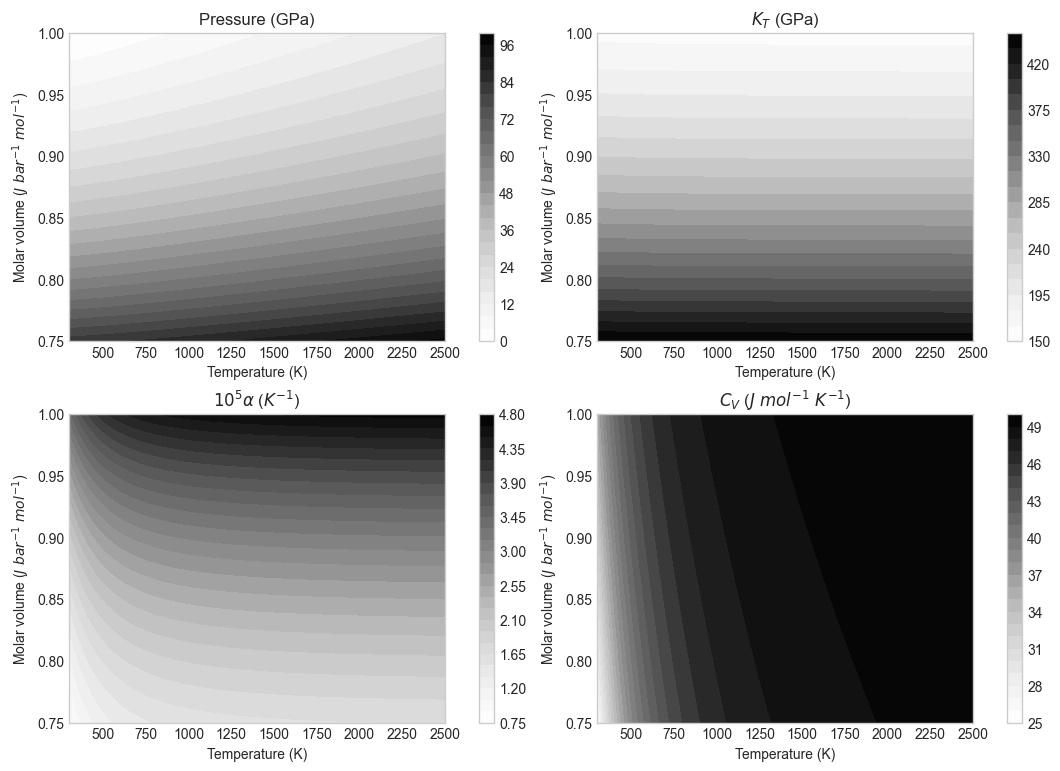

In [3]:
surfaces = [
    (pressure, "Pressure (GPa)"),
    (bulk_modulus, r"$K_T$ (GPa)"),
    (1e5 * expansivity, r"$10^5\alpha$ ($K^{-1}$)"),
    (heat_capacity_v, r"$C_V$ ($J\ mol^{-1}\ K^{-1}$)"),
]

fig, axes = plt.subplots(2, 2, figsize=(10.5, 7.6), constrained_layout=True)
for ax, (surface, title) in zip(axes.flat, surfaces):
    image = ax.contourf(temperature_axis, volume_axis, surface, levels=28)
    fig.colorbar(image, ax=ax)
    ax.set(title=title, xlabel="Temperature (K)", ylabel=r"Molar volume ($J\ bar^{-1}\ mol^{-1}$)")
plt.show()

## Trace and verify a 50 GPa isobar

At fixed pressure, increasing temperature requires a larger volume. Feeding
the solved volumes back into `pressure` and `temperature` checks both inverse
paths.

In [4]:
isobar_temperature = np.array([300.0, 1000.0, 1800.0, 2500.0])
isobar_pressure = np.full(isobar_temperature.shape, 50.0)
isobar_volume = eos.volume(isobar_pressure, isobar_temperature)

recovered_pressure = eos.pressure(isobar_volume, isobar_temperature)
recovered_temperature = eos.temperature(recovered_pressure, isobar_volume)

print(" T (K)   V (J bar^-1 mol^-1)   P recovered (GPa)   T recovered (K)")
for temperature, volume, p_back, t_back in zip(
    isobar_temperature,
    isobar_volume,
    recovered_pressure,
    recovered_temperature,
):
    print(f"{temperature:6.0f} {volume:21.6f} {p_back:19.8f} {t_back:17.6f}")

assert np.allclose(recovered_pressure, isobar_pressure)
assert np.allclose(recovered_temperature, isobar_temperature)

 T (K)   V (J bar^-1 mol^-1)   P recovered (GPa)   T recovered (K)
   300              0.813365         50.00000000        300.000000
  1000              0.824240         50.00000000       1000.000000
  1800              0.839594         50.00000000       1800.000000
  2500              0.854444         50.00000000       2500.000000


## Mechanical and caloric properties along the isobar

The caloric model also gives $C_P$ and the adiabatic modulus
$K_S=K_T C_P/C_V$. These are derived from one internally consistent state,
not from independently chosen curves.

In [5]:
kt = eos.bulk_modulus(isobar_volume, isobar_temperature)
cv = eos.molar_heat_capacity_v(isobar_volume, isobar_temperature)
cp = eos.molar_heat_capacity_p(isobar_volume, isobar_temperature)
ks = eos.adiabatic_bulk_modulus(isobar_volume, isobar_temperature)
gamma = eos.gruneisen_parameter(isobar_volume, isobar_temperature)

print(" T (K)     K_T      K_S       C_V       C_P    gamma")
for row in zip(isobar_temperature, kt, ks, cv, cp, gamma):
    print(
        f"{row[0]:6.0f} {row[1]:8.2f} {row[2]:8.2f} "
        f"{row[3]:9.3f} {row[4]:9.3f} {row[5]:8.3f}"
    )

assert np.allclose(ks, kt * cp / cv)

 T (K)     K_T      K_S       C_V       C_P    gamma
   300   342.43   344.00    28.744    28.876    1.220
  1000   325.46   334.23    47.283    48.557    1.236
  1800   304.73   321.43    49.099    51.788    1.259
  2500   286.28   310.07    49.494    53.606    1.282


## Takeaways

1. Broadcasting creates state surfaces without Python loops.
2. Thermal-model volume units are stricter than isothermal relative-volume
   calculations.
3. Pressure, inversion, derivatives, and caloric properties share one model
   and reference state.
4. Round-trip checks are inexpensive safeguards for multidimensional analyses.